In [12]:
#Importamos librerías básicas
import pandas as pd # manipulacion dataframes
import numpy as np  # matrices y vectores
import matplotlib.pyplot as plt #gráfica


In [13]:
# Se cargan los datos
df = pd.read_csv("Olist Store.csv") #Cargar datos en CSV
df.head() #muestras los 5 primeros registros

,customer_state,total_payment_value,payment_count,principal_payment_type,total_freight,total_weight_g,total_volume_cm3,seller_state_count,category_count,principal_category_by_price,principal_seller_state_by_price,distancia_km
0,SP,32.70,1.0,credit_card,12.80,200,2560,1,1,cama_mesa_banho,SP,309.131371
1,SP,54.36,1.0,credit_card,16.11,583,8400,1,1,brinquedos,SP,430.144201
2,SP,29.75,1.0,credit_card,11.85,250,4800,1,1,cama_mesa_banho,SP,209.757656
3,SP,118.86,1.0,boleto,8.96,525,4368,1,1,beleza_saude,SP,11.680956
4,SP,88.90,1.0,credit_card,8.91,250,3960,1,1,beleza_saude,SP,13.817425


In [14]:
#Se revisan los tipos de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25516 entries, 0 to 25515
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   customer_state                   25516 non-null  object 
 1   total_payment_value              25516 non-null  float64
 2   payment_count                    25516 non-null  float64
 3   principal_payment_type           25516 non-null  object 
 4   total_freight                    25516 non-null  float64
 5   total_weight_g                   25516 non-null  int64  
 6   total_volume_cm3                 25516 non-null  int64  
 7   seller_state_count               25516 non-null  int64  
 8   category_count                   25516 non-null  int64  
 9   principal_category_by_price      25516 non-null  object 
 10  principal_seller_state_by_price  25516 non-null  object 
 11  distancia_km                     25516 non-null  float64
dtypes: float64(4), int

In [15]:
#Corregir tipo de datos
df['customer_state']=df['customer_state'].astype('category')
df['principal_payment_type']=df['principal_payment_type'].astype('category')
df['principal_category_by_price']=df['principal_category_by_price'].astype('category')
df['principal_seller_state_by_price']=df['principal_seller_state_by_price'].astype('category')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25516 entries, 0 to 25515
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype   
---  ------                           --------------  -----   
 0   customer_state                   25516 non-null  category
 1   total_payment_value              25516 non-null  float64 
 2   payment_count                    25516 non-null  float64 
 3   principal_payment_type           25516 non-null  category
 4   total_freight                    25516 non-null  float64 
 5   total_weight_g                   25516 non-null  int64   
 6   total_volume_cm3                 25516 non-null  int64   
 7   seller_state_count               25516 non-null  int64   
 8   category_count                   25516 non-null  int64   
 9   principal_category_by_price      25516 non-null  category
 10  principal_seller_state_by_price  25516 non-null  category
 11  distancia_km                     25516 non-null  float64 
dtypes: c

In [16]:
#Describe estadística de variables númericas
df.describe()

,total_payment_value,payment_count,total_freight,total_weight_g,total_volume_cm3,seller_state_count,category_count,distancia_km
count,25516.000000,25516.000000,25516.000000,25516.000000,25516.000000,25516.000000,25516.000000,25516.000000
mean,139.729416,1.044562,17.467590,1996.635405,15455.276924,1.005016,1.006114,253.756260
std,165.401959,0.375015,13.461637,3889.021257,25635.042061,0.071751,0.079447,206.964231
min,9.590000,1.000000,0.000000,0.000000,352.000000,1.000000,1.000000,0.000000
25%,59.010000,1.000000,11.760000,314.750000,3132.500000,1.000000,1.000000,66.838875
50%,98.430000,1.000000,14.130000,800.000000,7326.000000,1.000000,1.000000,249.469462
75%,162.450000,1.000000,18.270000,1825.750000,18000.000000,1.000000,1.000000,365.650944
max,4445.500000,19.000000,388.100000,144300.000000,864000.000000,3.000000,3.000000,1328.639685


In [17]:
# Cargar librería para Profiling
!pip install ydata-profiling

In [18]:
# Perfilado de datos
from ydata_profiling import ProfileReport

profile_data=ProfileReport(df, minimal=True) # minimal=False
profile_data

ModuleNotFoundError: No module named 'pkg_resources'

In [20]:
#Guardamos en html el perfilado de datos
profile_data.to_file(output_file="output.html")

NameError: name 'profile_data' is not defined

In [21]:
#Copia de los datos
data=df.copy()

In [22]:
#Normalizacion de variables numéricas

from sklearn.preprocessing import MinMaxScaler


variables_a_normalizar=['total_payment_value', 'payment_count',  'total_freight',  'total_weight_g', 'total_volume_cm3', 'seller_state_count', 'category_count', 'distancia_km'] #variables numéricas

min_max_scaler = MinMaxScaler()

min_max_scaler.fit(data[variables_a_normalizar]) #Ajuste de parámetro
data[variables_a_normalizar]= min_max_scaler.transform(data[variables_a_normalizar])
data.head()

,customer_state,total_payment_value,payment_count,principal_payment_type,total_freight,total_weight_g,total_volume_cm3,seller_state_count,category_count,principal_category_by_price,principal_seller_state_by_price,distancia_km
0,SP,0.005210,0.0,credit_card,0.032981,0.001386,0.002557,0.0,0.0,cama_mesa_banho,SP,0.232668
1,SP,0.010093,0.0,credit_card,0.041510,0.004040,0.009319,0.0,0.0,brinquedos,SP,0.323748
2,SP,0.004545,0.0,credit_card,0.030533,0.001733,0.005150,0.0,0.0,cama_mesa_banho,SP,0.157874
3,SP,0.024633,0.0,boleto,0.023087,0.003638,0.004650,0.0,0.0,beleza_saude,SP,0.008792
4,SP,0.017879,0.0,credit_card,0.022958,0.001733,0.004178,0.0,0.0,beleza_saude,SP,0.010400


In [23]:
# Se crean dummies para las variables de 2 categorías
data = pd.get_dummies(data, columns=['customer_state'], drop_first=True, dtype=int)
data.head()

,total_payment_value,payment_count,principal_payment_type,total_freight,total_weight_g,total_volume_cm3,seller_state_count,category_count,principal_category_by_price,principal_seller_state_by_price,distancia_km,customer_state_SP
0,0.005210,0.0,credit_card,0.032981,0.001386,0.002557,0.0,0.0,cama_mesa_banho,SP,0.232668,1
1,0.010093,0.0,credit_card,0.041510,0.004040,0.009319,0.0,0.0,brinquedos,SP,0.323748,1
2,0.004545,0.0,credit_card,0.030533,0.001733,0.005150,0.0,0.0,cama_mesa_banho,SP,0.157874,1
3,0.024633,0.0,boleto,0.023087,0.003638,0.004650,0.0,0.0,beleza_saude,SP,0.008792,1
4,0.017879,0.0,credit_card,0.022958,0.001733,0.004178,0.0,0.0,beleza_saude,SP,0.010400,1


In [24]:
# mas de 2 categorías
data = pd.get_dummies(data, columns=['principal_payment_type', 'principal_category_by_price', 'principal_seller_state_by_price'], drop_first=True, dtype=int)
data.head()

,total_payment_value,payment_count,total_freight,total_weight_g,total_volume_cm3,seller_state_count,category_count,distancia_km,customer_state_SP,principal_payment_type_credit_card,...,principal_category_by_price_brinquedos,principal_category_by_price_cama_mesa_banho,principal_category_by_price_esporte_lazer,principal_category_by_price_informatica_acessorios,principal_category_by_price_moveis_decoracao,principal_category_by_price_relogios_presentes,principal_category_by_price_utilidades_domesticas,principal_seller_state_by_price_PR,principal_seller_state_by_price_RJ,principal_seller_state_by_price_SP
0,0.005210,0.0,0.032981,0.001386,0.002557,0.0,0.0,0.232668,1,1,...,0,1,0,0,0,0,0,0,0,1
1,0.010093,0.0,0.041510,0.004040,0.009319,0.0,0.0,0.323748,1,1,...,1,0,0,0,0,0,0,0,0,1
2,0.004545,0.0,0.030533,0.001733,0.005150,0.0,0.0,0.157874,1,1,...,0,1,0,0,0,0,0,0,0,1
3,0.024633,0.0,0.023087,0.003638,0.004650,0.0,0.0,0.008792,1,0,...,0,0,0,0,0,0,0,0,0,1
4,0.017879,0.0,0.022958,0.001733,0.004178,0.0,0.0,0.010400,1,1,...,0,0,0,0,0,0,0,0,0,1


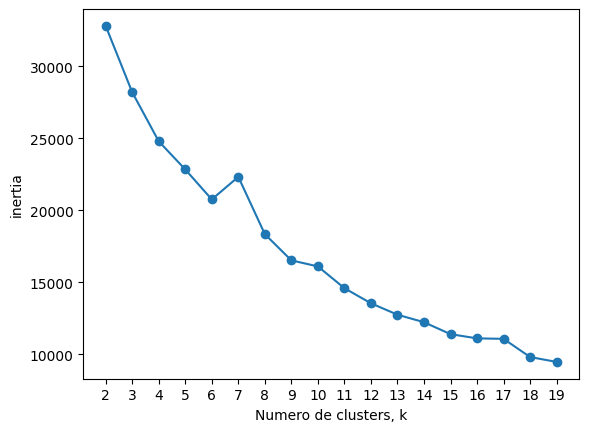

In [25]:
#Método del codo para encontrar la mejor cantidad de clusters: inertia
from sklearn.cluster import KMeans

ks = range(2, 20) # crear valores del 2 al 20
inertias = []

for k in ks:
    # Crear  modelo
    model = KMeans(n_clusters=k,max_iter=300)
    model.fit(data)
    inertias.append(model.inertia_)

# Graficar cantidad de clusters vs inertias
plt.plot(ks, inertias, '-o')
plt.xlabel('Numero de clusters, k')
plt.ylabel('inertia')
plt.xticks(ks)
plt.show()

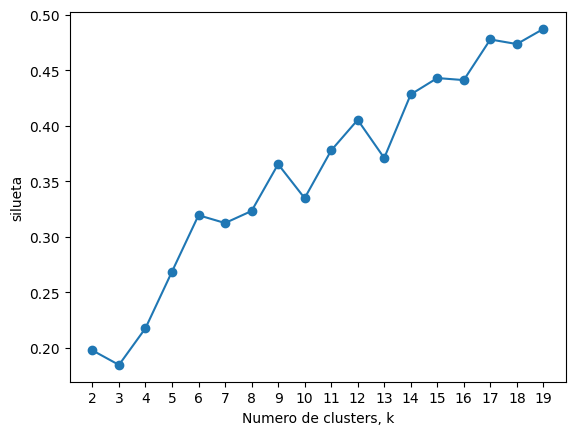

In [26]:
#Método de la rodilla: silueta
from sklearn import metrics

ks = range(2, 20) # crear valores del 2 al 20
siluetas = []

for k in ks:
    # Crear  modelo
    model = KMeans(n_clusters=k,max_iter=300)
    model.fit(data)
    sil=metrics.silhouette_score(data, model.labels_)
    siluetas.append(sil)

# Graficar cantidad de clusters vs inertias

plt.plot(ks, siluetas, '-o')
plt.xlabel('Numero de clusters, k')
plt.ylabel('silueta')
plt.xticks(ks)
plt.show()

In [27]:
#Creación de modelo de clustering con Kmeans
from sklearn.cluster import KMeans
k=3
model = KMeans(n_clusters=k, max_iter=300)
model.fit(data) #100% datos

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](3, 22)"

In [28]:
#Evaluación
from sklearn import metrics

#Inertia: se require valor pequeño
print('Inercia o cohesión:', model.inertia_)

#Silueta: se requiere que sea positivo, ideal 0.5-1.0
sil=metrics.silhouette_score(data, model.labels_)
print('Silueta:',sil)

Inercia o cohesión: 28282.5063102617
Silueta: 0.1791498036105093


In [ ]:
#Centroides almacenadas dentro del modelo
model.cluster_centers_

array([[ 4.20351992e-02,  1.56031863e-03,  4.48024974e-02,
         8.50878339e-03,  1.22893535e-02,  6.28233555e-03,
         1.10864745e-03,  1.98189501e-01,  5.49889135e-01,
         8.22616408e-01,  1.40428677e-02,  1.99556541e-02,
         1.86252772e-01,  4.43458980e-02,  1.36733186e-01,
         3.99113082e-02,  3.69549150e-02,  1.43385070e-01,
         4.58240946e-02, -4.02455846e-16,  9.51958610e-01,
        -7.43849426e-15],
       [ 2.59281691e-02,  3.61322784e-03,  4.63233722e-02,
         1.59636129e-02,  2.17915803e-02,  2.47729149e-03,
         4.23203964e-03,  2.08935078e-01,  7.98926507e-01,
         7.78282411e-01,  1.44508671e-02,  3.79851363e-02,
         1.23512311e-15,  1.00000000e+00,  1.13520304e-14,
         3.06699111e-15, -3.58046925e-15, -6.61970478e-15,
         7.34134975e-15, -4.30211422e-16,  2.76861867e-15,
         9.67795211e-01],
       [ 3.56994658e-02,  2.16555353e-03,  5.94079794e-02,
         1.30973773e-02,  1.54562245e-02,  6.37522769e-03,
    

In [30]:
centroides.columns

Index(['total_payment_value', 'payment_count', 'total_freight',
       'total_weight_g', 'total_volume_cm3', 'seller_state_count',
       'category_count', 'distancia_km', 'customer_state_SP',
       'principal_payment_type_credit_card',
       'principal_payment_type_debit_card', 'principal_payment_type_voucher',
       'principal_category_by_price_brinquedos',
       'principal_category_by_price_cama_mesa_banho',
       'principal_category_by_price_esporte_lazer',
       'principal_category_by_price_informatica_acessorios',
       'principal_category_by_price_moveis_decoracao',
       'principal_category_by_price_relogios_presentes',
       'principal_category_by_price_utilidades_domesticas',
       'principal_seller_state_by_price_PR',
       'principal_seller_state_by_price_RJ',
       'principal_seller_state_by_price_SP'],
      dtype='object')

In [29]:
#Centroides de los cluster se convierten  en un dataframe de pandas
centroides=pd.DataFrame(model.cluster_centers_,columns=data.columns.values)
centroides.round(1)

,total_payment_value,payment_count,total_freight,total_weight_g,total_volume_cm3,seller_state_count,category_count,distancia_km,customer_state_SP,principal_payment_type_credit_card,...,principal_category_by_price_brinquedos,principal_category_by_price_cama_mesa_banho,principal_category_by_price_esporte_lazer,principal_category_by_price_informatica_acessorios,principal_category_by_price_moveis_decoracao,principal_category_by_price_relogios_presentes,principal_category_by_price_utilidades_domesticas,principal_seller_state_by_price_PR,principal_seller_state_by_price_RJ,principal_seller_state_by_price_SP
0,0.0,0.0,0.1,0.0,0.0,0.0,0.0,0.3,0.7,0.8,...,0.1,0.0,0.2,0.2,0.1,0.1,0.1,0.4,0.2,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.2,0.8,1.0,...,0.1,0.3,0.1,0.1,0.1,-0.0,0.1,-0.0,0.0,1.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.2,0.8,0.3,...,0.0,0.2,0.1,0.1,0.1,0.3,0.1,-0.0,0.0,1.0


In [31]:
# Se realiza una des-normalización centroides
centroides[variables_a_normalizar]=min_max_scaler.inverse_transform(centroides[variables_a_normalizar])
centroides.round(0)

,total_payment_value,payment_count,total_freight,total_weight_g,total_volume_cm3,seller_state_count,category_count,distancia_km,customer_state_SP,principal_payment_type_credit_card,...,principal_category_by_price_brinquedos,principal_category_by_price_cama_mesa_banho,principal_category_by_price_esporte_lazer,principal_category_by_price_informatica_acessorios,principal_category_by_price_moveis_decoracao,principal_category_by_price_relogios_presentes,principal_category_by_price_utilidades_domesticas,principal_seller_state_by_price_PR,principal_seller_state_by_price_RJ,principal_seller_state_by_price_SP
0,170.0,1.0,22.0,2083.0,14540.0,1.0,1.0,430.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,124.0,1.0,17.0,2181.0,17556.0,1.0,1.0,208.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,-0.0,0.0,1.0
2,147.0,1.0,15.0,1545.0,11836.0,1.0,1.0,207.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,1.0


DESCRIPCIÓN DE PERFILES  *  pendiente

> Agregar bloque entrecomillado



In [ ]:
#En el dataframe original, se adiciona el cluster asignado a cada registro
df['cluster']=model.labels_
df.head()

,customer_state,total_payment_value,payment_count,principal_payment_type,total_freight,total_weight_g,total_volume_cm3,seller_state_count,category_count,principal_category_by_price,principal_seller_state_by_price,distancia_km,cluster
0,SP,32.70,1.0,credit_card,12.80,200,2560,1,1,cama_mesa_banho,SP,309.131371,1
1,SP,54.36,1.0,credit_card,16.11,583,8400,1,1,brinquedos,SP,430.144201,5
2,SP,29.75,1.0,credit_card,11.85,250,4800,1,1,cama_mesa_banho,SP,209.757656,1
3,SP,118.86,1.0,boleto,8.96,525,4368,1,1,beleza_saude,SP,11.680956,12
4,SP,88.90,1.0,credit_card,8.91,250,3960,1,1,beleza_saude,SP,13.817425,9


<Axes: ylabel='count'>

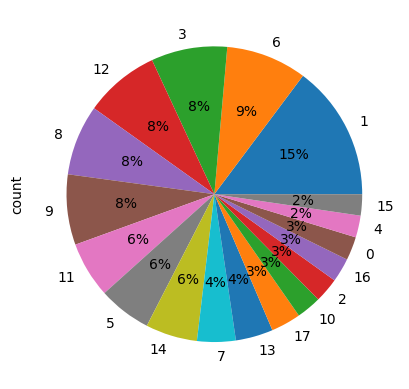

In [ ]:
#Cantidad de datos en cada cluster
df["cluster"].value_counts().plot(kind='pie',autopct='%.0f%%')

In [ ]:
#Almacenar resultados
df.to_excel('./resultados_Kmeans.xlsx')
centroides.to_excel('./centroides.xlsx')